In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Setup successful!")

Setup successful!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving 13614778-QuickCart_Stockout_Risk_Project_Spec_(2).zip to 13614778-QuickCart_Stockout_Risk_Project_Spec_(2) (1).zip


In [3]:
import os

print(os.listdir())

['.config', '13614778-QuickCart_Stockout_Risk_Project_Spec_(2).zip', '13614778-QuickCart_Stockout_Risk_Project_Spec_(2) (1).zip', 'sample_data']


In [4]:
import zipfile
import os

zip_files = [
    '13614778-QuickCart_Stockout_Risk_Project_Spec_(2).zip',
    '13614778-QuickCart_Stockout_Risk_Project_Spec_(2) (1).zip'
]

for z in zip_files:
    print("\n---", z, "---")
    with zipfile.ZipFile(z, 'r') as zip_ref:
        files_in_zip = zip_ref.namelist()
        for f in files_in_zip:
            print(f)


--- 13614778-QuickCart_Stockout_Risk_Project_Spec_(2).zip ---
QuickCart_Stockout_Risk_Project_Spec.pdf
dim_events.zip

--- 13614778-QuickCart_Stockout_Risk_Project_Spec_(2) (1).zip ---
QuickCart_Stockout_Risk_Project_Spec.pdf
dim_events.zip


In [5]:
import zipfile
import os

project_zip = '13614778-QuickCart_Stockout_Risk_Project_Spec_(2).zip'

with zipfile.ZipFile(project_zip, 'r') as zip_ref:
    zip_ref.extractall('quickcart')

print("Project ZIP extracted!")
print(os.listdir('quickcart'))

Project ZIP extracted!
['QuickCart_Stockout_Risk_Project_Spec.pdf', 'dim_events.zip']


In [6]:
import zipfile
import os

events_zip = 'quickcart/dim_events.zip'

with zipfile.ZipFile(events_zip, 'r') as zip_ref:
    zip_ref.extractall('quickcart/data')

print("dim_events.zip extracted!")
print(os.listdir('quickcart/data'))


dim_events.zip extracted!
['dim_suppliers.csv', 'dim_skus.csv', 'dim_stores.csv', 'dim_events.csv', 'fact_inventory_daily.csv']


In [7]:
import pandas as pd

path = "quickcart/data/"

stores = pd.read_csv(path + "dim_stores.csv")
skus = pd.read_csv(path + "dim_skus.csv")
suppliers = pd.read_csv(path + "dim_suppliers.csv")
events = pd.read_csv(path + "dim_events.csv")
inventory = pd.read_csv(path + "fact_inventory_daily.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [8]:
print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [9]:
print("STORES")
print(stores.columns.tolist())

print("\nSKUS")
print(skus.columns.tolist())

print("\nSUPPLIERS")
print(suppliers.columns.tolist())

print("\nEVENTS")
print(events.columns.tolist())

print("\nINVENTORY")
print(inventory.columns.tolist())

STORES
['store_id', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders']

SKUS
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

SUPPLIERS
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']

EVENTS
['date', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other']

INVENTORY
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk']


In [10]:
inventory["date"] = pd.to_datetime(inventory["date"])

print("First date:", inventory["date"].min())
print("Last date:", inventory["date"].max())
print("Number of dates:", inventory["date"].nunique())

First date: 2026-10-01 00:00:00
Last date: 2026-10-30 00:00:00
Number of dates: 30


In [11]:
print(inventory["stockout_risk"].value_counts())

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [12]:
print(
    inventory["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


In [13]:
print(inventory.isnull().sum())

date                           0
store_id                       0
sku_id                         0
supplier_id                    0
opening_stock                  0
units_demanded                 0
units_sold                     0
closing_stock                  0
reorder_point                  0
reorder_placed                 0
lead_time_days_expected        0
lead_time_days_actual      19899
sales_velocity_7d              0
days_of_cover                  0
is_festival_week               0
stockout_risk                  0
dtype: int64


In [14]:
print(
    "Missing actual lead time:",
    inventory["lead_time_days_actual"].isna().sum()
)

Missing actual lead time: 19899


In [15]:
suppliers["reliability_score"] = pd.to_numeric(
    suppliers["reliability_score"],
    errors="coerce"
)

print(
    "Missing reliability before cleaning:",
    suppliers["reliability_score"].isna().sum()
)

Missing reliability before cleaning: 3


In [16]:
median_reliability = suppliers["reliability_score"].median()

suppliers["reliability_score"] = suppliers[
    "reliability_score"
].fillna(median_reliability)

print(
    "Missing reliability after cleaning:",
    suppliers["reliability_score"].isna().sum()
)

Missing reliability after cleaning: 0


In [19]:
# Convert both date columns to the same format
inventory["date"] = pd.to_datetime(inventory["date"])
events["date"] = pd.to_datetime(events["date"])

# Start fresh
df = inventory.copy()

# 1. Merge Stores
df = df.merge(
    stores,
    on="store_id",
    how="left"
)

# 2. Merge SKUs
# Remove supplier_id because inventory already contains it
skus_merge = skus.drop(columns=["supplier_id"])

df = df.merge(
    skus_merge,
    on="sku_id",
    how="left"
)

# 3. Merge Suppliers
df = df.merge(
    suppliers,
    on="supplier_id",
    how="left"
)

# 4. Merge Events
df = df.merge(
    events,
    on="date",
    how="left"
)

print("Master dataset created successfully!")
print("Shape:", df.shape)

Master dataset created successfully!
Shape: (21600, 39)


In [20]:
print("Rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Rows: 21600
Duplicate rows: 0


In [21]:
print("Missing store information:", df["city"].isna().sum())
print("Missing SKU information:", df["sku_name"].isna().sum())
print("Missing supplier information:", df["supplier_name"].isna().sum())
print("Missing event information:", df["event_name"].isna().sum())

Missing store information: 0
Missing SKU information: 0
Missing supplier information: 0
Missing event information: 0


In [22]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (21600, 39)

Data types:
date                         datetime64[ns]
store_id                             object
sku_id                               object
supplier_id                          object
opening_stock                       float64
units_demanded                        int64
units_sold                          float64
closing_stock                       float64
reorder_point                       float64
reorder_placed                       object
lead_time_days_expected               int64
lead_time_days_actual               float64
sales_velocity_7d                   float64
days_of_cover                       float64
is_festival_week                     object
stockout_risk                        object
city                                 object
city_display                         object
city_tier                            object
store_size                           object
sqft                                  int64
opened_year                         

In [23]:
df.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,popularity_tier,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


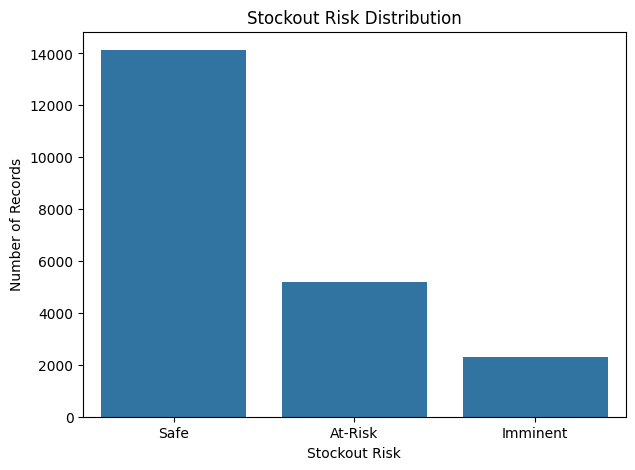

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="stockout_risk"
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Records")

plt.show()

In [25]:
risk_pct = (
    df["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_pct)

stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


The target variable is imbalanced, with Safe representing approximately 65.42% of observations, At-Risk 24.01%, and Imminent 10.57%. Therefore, model evaluation should not rely on accuracy alone.

In [26]:
festival_risk = pd.crosstab(
    df["is_festival_week"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(festival_risk.round(2))

stockout_risk     At-Risk  Imminent   Safe
is_festival_week                          
N                   24.19      9.51  66.30
Y                   21.80     23.31  54.89


<Figure size 800x500 with 0 Axes>

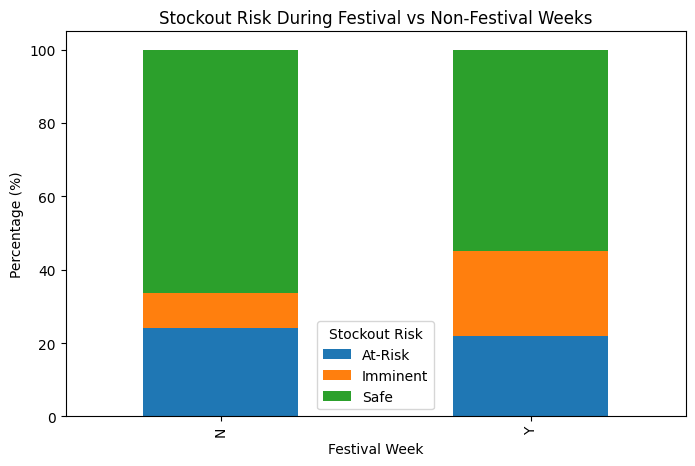

In [27]:
plt.figure(figsize=(8,5))

festival_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Stockout Risk During Festival vs Non-Festival Weeks")
plt.xlabel("Festival Week")
plt.ylabel("Percentage (%)")
plt.legend(title="Stockout Risk")

plt.show()

In [28]:
non_festival = festival_risk.loc["N", "Imminent"]
festival = festival_risk.loc["Y", "Imminent"]

print("Non-festival Imminent:", round(non_festival, 2), "%")
print("Festival Imminent:", round(festival, 2), "%")
print("Risk multiplier:", round(festival / non_festival, 2), "x")

Non-festival Imminent: 9.51 %
Festival Imminent: 23.31 %
Risk multiplier: 2.45 x


Business insight

Festival periods significantly increase stockout risk. The Imminent risk rate is approximately 2.45 times higher during festival weeks, indicating that inventory buffers and replenishment should be increased before major demand events.

In [29]:
print(df["reliability_score"].describe())

count    21600.000000
mean         0.751833
std          0.094989
min          0.630000
25%          0.700000
50%          0.725000
75%          0.830000
max          0.930000
Name: reliability_score, dtype: float64


In [30]:
df["reliability_group"] = pd.cut(
    df["reliability_score"],
    bins=[-np.inf, 0.75, 0.85, np.inf],
    labels=["Low", "Medium", "High"],
    right=False
)

In [31]:
supplier_risk = pd.crosstab(
    df["reliability_group"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(supplier_risk.round(2))

stockout_risk      At-Risk  Imminent   Safe
reliability_group                          
Low                  21.63     13.07  65.30
Medium               17.57      3.26  79.17
High                 34.88      3.82  61.30


<Figure size 800x500 with 0 Axes>

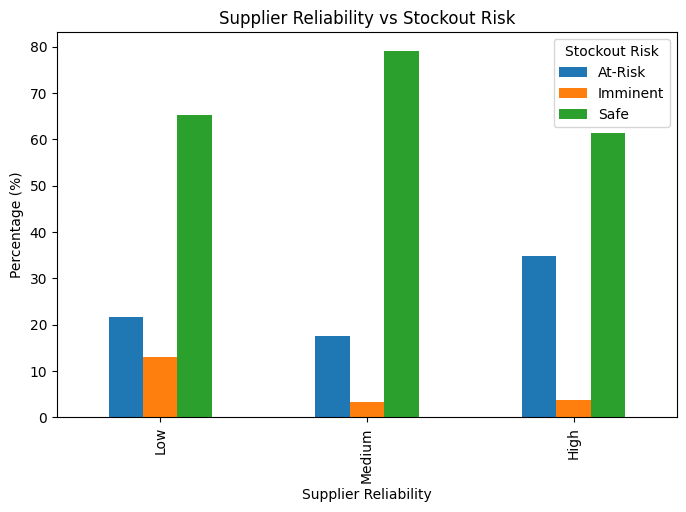

In [32]:
plt.figure(figsize=(8,5))

supplier_risk.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Supplier Reliability vs Stockout Risk")
plt.xlabel("Supplier Reliability")
plt.ylabel("Percentage (%)")
plt.legend(title="Stockout Risk")

plt.show()

Business insight

Lower supplier reliability is strongly associated with higher stockout risk. Therefore, supplier reliability should be incorporated into replenishment planning and supplier selection.

In [33]:
print(df["is_perishable"].value_counts())

is_perishable
N    13680
Y     7920
Name: count, dtype: int64


In [34]:
perishable_risk = pd.crosstab(
    df["is_perishable"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(perishable_risk.round(2))

stockout_risk  At-Risk  Imminent   Safe
is_perishable                          
N                24.64      9.30  66.06
Y                22.92     12.77  64.32


<Figure size 800x500 with 0 Axes>

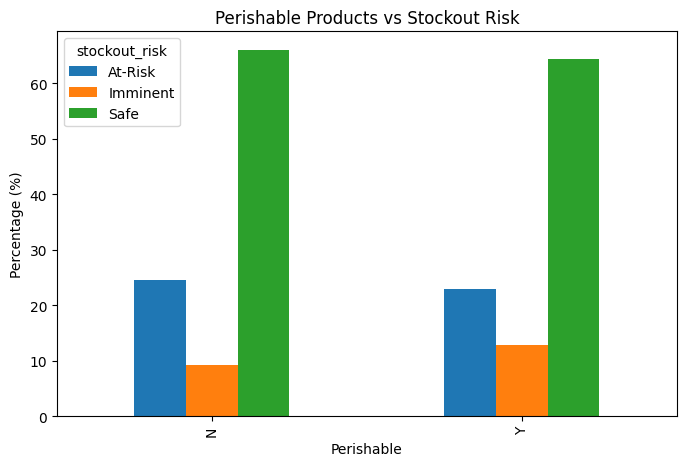

In [35]:
plt.figure(figsize=(8,5))

perishable_risk.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Perishable Products vs Stockout Risk")
plt.xlabel("Perishable")
plt.ylabel("Percentage (%)")

plt.show()

Business insight

Perishable products show somewhat higher stockout risk, suggesting that their shorter shelf life and replenishment constraints require careful inventory planning.

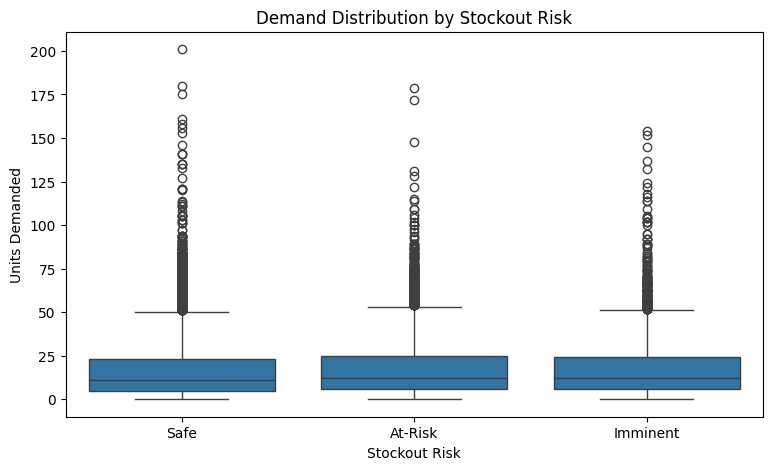

In [36]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="stockout_risk",
    y="units_demanded"
)

plt.title("Demand Distribution by Stockout Risk")
plt.xlabel("Stockout Risk")
plt.ylabel("Units Demanded")

plt.show()

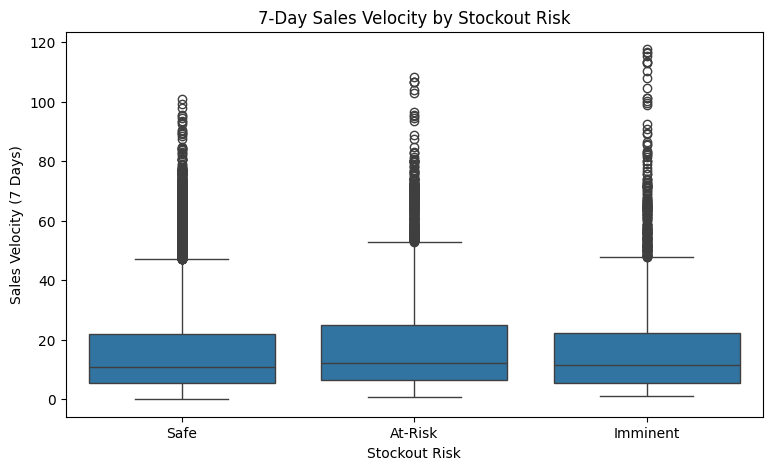

In [37]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="stockout_risk",
    y="sales_velocity_7d"
)

plt.title("7-Day Sales Velocity by Stockout Risk")
plt.xlabel("Stockout Risk")
plt.ylabel("Sales Velocity (7 Days)")

plt.show()

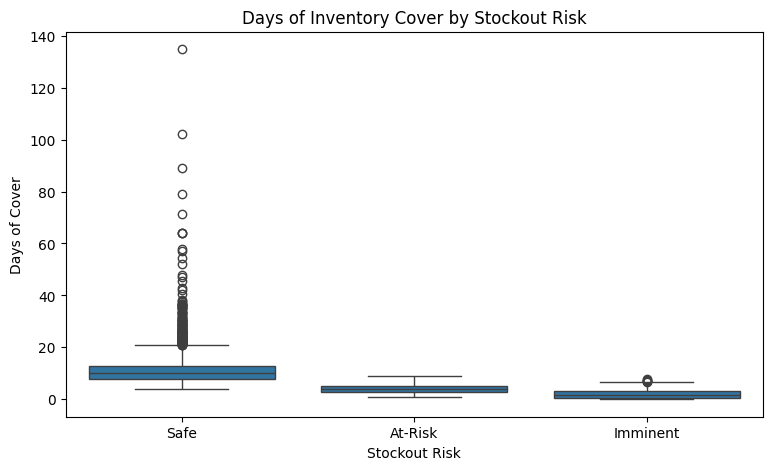

In [38]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="stockout_risk",
    y="days_of_cover"
)

plt.title("Days of Inventory Cover by Stockout Risk")
plt.xlabel("Stockout Risk")
plt.ylabel("Days of Cover")

plt.show()

Business meaning

Lower days of cover generally means inventory is closer to being depleted.

In [39]:
df["reorder_gap"] = (
    df["reorder_point"] - df["closing_stock"]
)

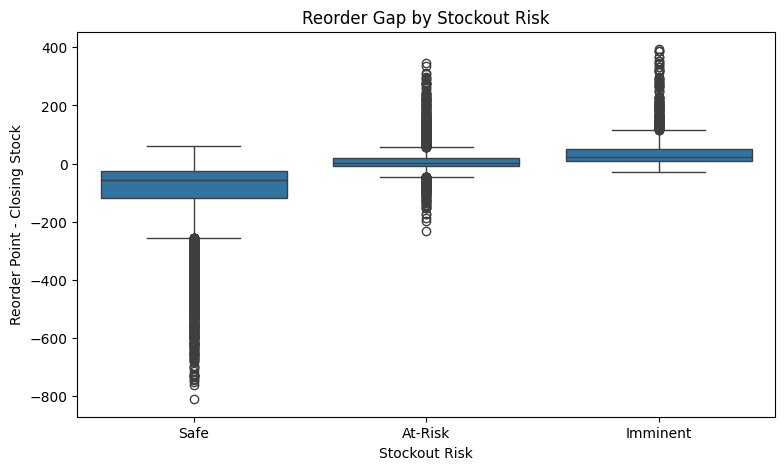

In [40]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="stockout_risk",
    y="reorder_gap"
)

plt.title("Reorder Gap by Stockout Risk")
plt.xlabel("Stockout Risk")
plt.ylabel("Reorder Point - Closing Stock")

plt.show()

In [41]:
numeric_cols = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "lead_time_days_expected",
    "sales_velocity_7d",
    "days_of_cover",
    "reliability_score",
    "unit_price_inr",
    "shelf_life_days",
    "reorder_gap"
]

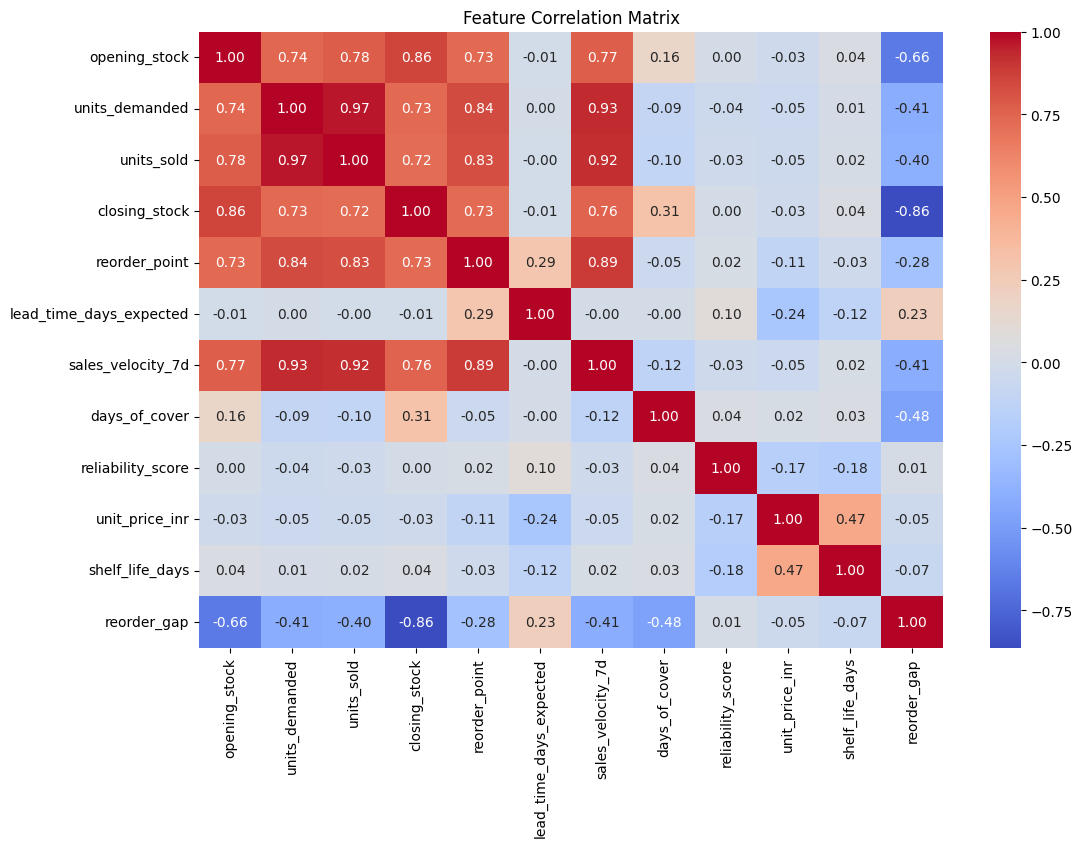

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [43]:
df.to_csv(
    "quickcart_master_dataset.csv",
    index=False
)

print("Master dataset saved successfully!")

Master dataset saved successfully!


In [44]:
print("Target distribution:")
print(df["stockout_risk"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Missing values:
lead_time_days_actual    19899
store_id                     0
sku_id                       0
supplier_id                  0
opening_stock                0
units_demanded               0
units_sold                   0
closing_stock                0
date                         0
reorder_point                0
dtype: int64


In [45]:
df["is_perishable"] = (
    df["is_perishable"] == "Y"
).astype(int)

df["festive_relevant"] = (
    df["festive_relevant"] == "Y"
).astype(int)

df["festival_flag"] = (
    df["is_festival_week"] == "Y"
).astype(int)

df["reorder_flag"] = (
    df["reorder_placed"] == "Y"
).astype(int)

In [46]:
print(df[[
    "is_perishable",
    "festive_relevant",
    "festival_flag",
    "reorder_flag"
]].head())

   is_perishable  festive_relevant  festival_flag  reorder_flag
0              1                 0              0             0
1              1                 0              0             0
2              1                 0              0             0
3              1                 0              0             0
4              1                 0              0             0


In [47]:
df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"].replace(0, np.nan)
)

df["stock_demand_ratio"] = (
    df["closing_stock"] /
    df["units_demanded"].replace(0, np.nan)
)

df["demand_gap"] = (
    df["units_demanded"] -
    df["units_sold"]
)

df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

df["weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [48]:
new_features = [
    "reorder_gap",
    "days_of_cover_ratio",
    "stock_demand_ratio",
    "demand_gap",
    "day_of_month",
    "day_of_week",
    "weekend"
]

print(df[new_features].describe())

        reorder_gap  days_of_cover_ratio  stock_demand_ratio    demand_gap  \
count  21600.000000         21600.000000        21209.000000  21600.000000   
mean     -53.536347             4.696304            8.666266      0.524815   
std      104.712819             4.491873            6.898383      4.397780   
min     -810.000000             0.000000            0.000000      0.000000   
25%      -78.500000             1.628000            4.236957      0.000000   
50%      -26.300000             3.143333            7.346154      0.000000   
75%        0.000000             6.480000           11.285714      0.000000   
max      393.500000           134.850000           91.000000    144.800000   

       day_of_month   day_of_week       weekend  
count  21600.000000  21600.000000  21600.000000  
mean      15.500000      3.033333      0.266667  
std        8.655642      1.940549      0.442227  
min        1.000000      0.000000      0.000000  
25%        8.000000      1.000000      0.000000

In [49]:
features = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "lead_time_days_expected",
    "sales_velocity_7d",
    "days_of_cover",
    "reorder_gap",
    "days_of_cover_ratio",
    "stock_demand_ratio",
    "demand_gap",
    "reliability_score",
    "base_lead_time_days",
    "lead_time_variance_days",
    "shelf_life_days",
    "unit_price_inr",
    "is_perishable",
    "festive_relevant",
    "festival_flag",
    "day_of_month",
    "day_of_week",
    "weekend"
]

target = "stockout_risk"

In [50]:
model_df = df[
    features + [target, "date"]
].dropna()

print("Original rows:", len(df))
print("Rows used for ML:", len(model_df))
print("Rows removed:", len(df) - len(model_df))

Original rows: 21600
Rows used for ML: 21209
Rows removed: 391


In [51]:
train = model_df[
    model_df["date"] <= "2026-10-23"
].copy()

test = model_df[
    model_df["date"] >= "2026-10-24"
].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 16238
Testing rows: 4971


In [52]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16238, 23)
X_test: (4971, 23)


In [53]:
print("TRAIN")
print(y_train.value_counts())
print()

print("TEST")
print(y_test.value_counts())

TRAIN
stockout_risk
Safe        10734
At-Risk      4020
Imminent     1484
Name: count, dtype: int64

TEST
stockout_risk
Safe        3086
At-Risk     1120
Imminent     765
Name: count, dtype: int64


In [54]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print(
    classification_report(
        y_test,
        baseline_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     At-Risk      0.000     0.000     0.000      1120
    Imminent      0.000     0.000     0.000       765
        Safe      0.621     1.000     0.766      3086

    accuracy                          0.621      4971
   macro avg      0.207     0.333     0.255      4971
weighted avg      0.385     0.621     0.476      4971



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [57]:
class_weight="balanced"

In [58]:
logistic = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic.fit(X_train, y_train)

logistic_pred = logistic.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
print(
    classification_report(
        y_test,
        logistic_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     At-Risk      0.881     0.656     0.752      1120
    Imminent      0.669     0.929     0.778       765
        Safe      0.989     0.985     0.987      3086

    accuracy                          0.903      4971
   macro avg      0.846     0.857     0.839      4971
weighted avg      0.916     0.903     0.902      4971



In [60]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [61]:
print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     At-Risk      0.785     0.956     0.862      1120
    Imminent      0.910     0.620     0.737       765
        Safe      0.999     0.999     0.999      3086

    accuracy                          0.931      4971
   macro avg      0.898     0.858     0.866      4971
weighted avg      0.937     0.931     0.928      4971



In [62]:
print("=" * 60)
print("BASELINE")
print("=" * 60)

print(
    classification_report(
        y_test,
        baseline_pred,
        digits=3
    )
)

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        digits=3
    )
)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

BASELINE
              precision    recall  f1-score   support

     At-Risk      0.000     0.000     0.000      1120
    Imminent      0.000     0.000     0.000       765
        Safe      0.621     1.000     0.766      3086

    accuracy                          0.621      4971
   macro avg      0.207     0.333     0.255      4971
weighted avg      0.385     0.621     0.476      4971

LOGISTIC REGRESSION
              precision    recall  f1-score   support

     At-Risk      0.881     0.656     0.752      1120
    Imminent      0.669     0.929     0.778       765
        Safe      0.989     0.985     0.987      3086

    accuracy                          0.903      4971
   macro avg      0.846     0.857     0.839      4971
weighted avg      0.916     0.903     0.902      4971

RANDOM FOREST
              precision    recall  f1-score   support

     At-Risk      0.785     0.956     0.862      1120
    Imminent      0.910     0.620     0.737       765
        Safe      0.999     0.99

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


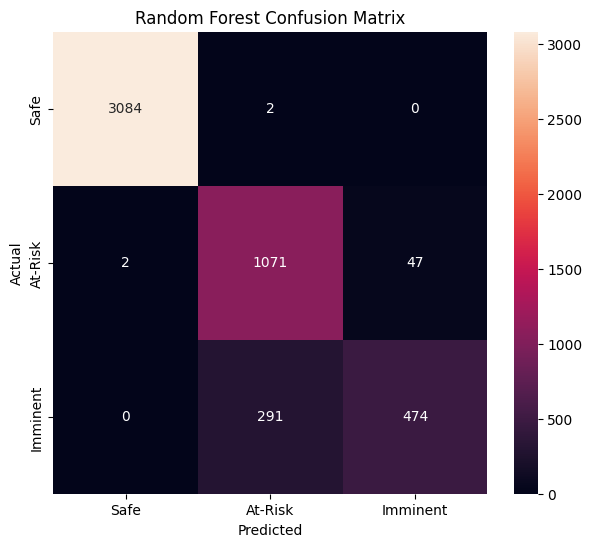

In [63]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Safe", "At-Risk", "Imminent"],
    yticklabels=["Safe", "At-Risk", "Imminent"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [64]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
7             days_of_cover    0.184301
9       days_of_cover_ratio    0.181782
8               reorder_gap    0.179105
10       stock_demand_ratio    0.129217
3             closing_stock    0.048423
0             opening_stock    0.031139
6         sales_velocity_7d    0.030317
12        reliability_score    0.029126
4             reorder_point    0.028130
20             day_of_month    0.020612
14  lead_time_variance_days    0.017453
5   lead_time_days_expected    0.017358
2                units_sold    0.017231
1            units_demanded    0.016834
13      base_lead_time_days    0.015668
16           unit_price_inr    0.014472
15          shelf_life_days    0.014457
21              day_of_week    0.011031
17            is_perishable    0.003206
18         festive_relevant    0.003098
11               demand_gap    0.002839
22                  weekend    0.002674
19            festival_flag    0.001529


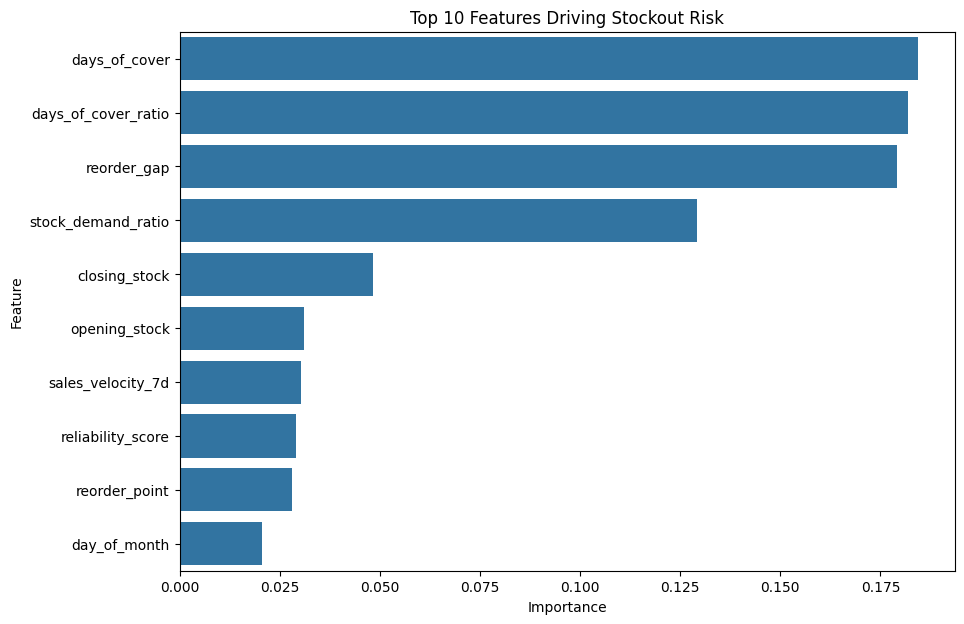

In [65]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Driving Stockout Risk")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [67]:
# Create prediction results from the original test data
results = test.copy()

# Add model predictions
results["predicted_risk"] = rf_pred

# Show predictions
print(results[
    [
        "date",
        "stockout_risk",
        "predicted_risk"
    ]
].head(20))

          date stockout_risk predicted_risk
23  2026-10-24       At-Risk        At-Risk
24  2026-10-25          Safe           Safe
25  2026-10-26          Safe           Safe
26  2026-10-27          Safe           Safe
27  2026-10-28          Safe           Safe
28  2026-10-29          Safe           Safe
29  2026-10-30          Safe           Safe
53  2026-10-24          Safe           Safe
54  2026-10-25          Safe           Safe
55  2026-10-26          Safe           Safe
56  2026-10-27       At-Risk        At-Risk
59  2026-10-30          Safe           Safe
83  2026-10-24          Safe           Safe
84  2026-10-25          Safe           Safe
85  2026-10-26          Safe           Safe
86  2026-10-27          Safe           Safe
87  2026-10-28          Safe           Safe
88  2026-10-29          Safe           Safe
89  2026-10-30          Safe           Safe
113 2026-10-24          Safe           Safe


In [68]:
# Get the original test records
result_ids = df.loc[
    df["date"] >= "2026-10-24",
    ["date", "store_id", "sku_id"]
].copy()

# Reset indexes
result_ids = result_ids.reset_index(drop=True)
results = results.reset_index(drop=True)

# Add IDs
results["store_id"] = result_ids["store_id"]
results["sku_id"] = result_ids["sku_id"]

# Display final prediction table
results[
    [
        "date",
        "store_id",
        "sku_id",
        "stockout_risk",
        "predicted_risk"
    ]
].head(20)

,date,store_id,sku_id,stockout_risk,predicted_risk
0,2026-10-24,ST01,SKU001,At-Risk,At-Risk
1,2026-10-25,ST01,SKU001,Safe,Safe
2,2026-10-26,ST01,SKU001,Safe,Safe
3,2026-10-27,ST01,SKU001,Safe,Safe
4,2026-10-28,ST01,SKU001,Safe,Safe
5,2026-10-29,ST01,SKU001,Safe,Safe
6,2026-10-30,ST01,SKU001,Safe,Safe
7,2026-10-24,ST02,SKU001,Safe,Safe
8,2026-10-25,ST02,SKU001,Safe,Safe
9,2026-10-26,ST02,SKU001,Safe,Safe


In [69]:
results.to_csv(
    "quickcart_stockout_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [70]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_results = []

for name, predictions in [
    ("Baseline", baseline_pred),
    ("Logistic Regression", logistic_pred),
    ("Random Forest", rf_pred)
]:

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Imminent Precision": precision_score(
            y_test,
            predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent Recall": recall_score(
            y_test,
            predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent F1": f1_score(
            y_test,
            predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    })

model_results = pd.DataFrame(model_results)

model_results.round(3)

,Model,Accuracy,Balanced Accuracy,Imminent Precision,Imminent Recall,Imminent F1
0,Baseline,0.621,0.333,0.000,0.000,0.000
1,Logistic Regression,0.903,0.857,0.669,0.929,0.778
2,Random Forest,0.931,0.858,0.910,0.620,0.737


In [71]:
print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     At-Risk      0.785     0.956     0.862      1120
    Imminent      0.910     0.620     0.737       765
        Safe      0.999     0.999     0.999      3086

    accuracy                          0.931      4971
   macro avg      0.898     0.858     0.866      4971
weighted avg      0.937     0.931     0.928      4971



In [72]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

print(pd.DataFrame(
    cm,
    index=["Actual Safe", "Actual At-Risk", "Actual Imminent"],
    columns=["Pred Safe", "Pred At-Risk", "Pred Imminent"]
))

                 Pred Safe  Pred At-Risk  Pred Imminent
Actual Safe           3084             2              0
Actual At-Risk           2          1071             47
Actual Imminent          0           291            474


In [73]:
rf_prob = rf.predict_proba(X_test)

print(rf.classes_)

['At-Risk' 'Imminent' 'Safe']


In [74]:
# Get probability of each class
prob_df = pd.DataFrame(
    rf_prob,
    columns=rf.classes_
)

# Start with normal predictions
threshold_pred = rf.predict(X_test)

# If Imminent probability is >= 0.25,
# classify as Imminent
threshold_pred[
    prob_df["Imminent"] >= 0.25
] = "Imminent"

print(
    classification_report(
        y_test,
        threshold_pred,
        digits=3
    )
)


              precision    recall  f1-score   support

     At-Risk      0.893     0.854     0.873      1120
    Imminent      0.802     0.852     0.826       765
        Safe      0.999     0.999     0.999      3086

    accuracy                          0.944      4971
   macro avg      0.898     0.902     0.900      4971
weighted avg      0.945     0.944     0.944      4971



In [75]:
cm_threshold = confusion_matrix(
    y_test,
    threshold_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

print(pd.DataFrame(
    cm_threshold,
    index=["Actual Safe", "Actual At-Risk", "Actual Imminent"],
    columns=["Pred Safe", "Pred At-Risk", "Pred Imminent"]
))

                 Pred Safe  Pred At-Risk  Pred Imminent
Actual Safe           3084             2              0
Actual At-Risk           2           957            161
Actual Imminent          0           113            652


In [76]:
# Proper time-based split

train_final = model_df[
    model_df["date"] <= "2026-10-18"
].copy()

validation = model_df[
    (model_df["date"] >= "2026-10-19") &
    (model_df["date"] <= "2026-10-23")
].copy()

test_final = model_df[
    model_df["date"] >= "2026-10-24"
].copy()

print("Training:", len(train_final))
print("Validation:", len(validation))
print("Final Test:", len(test_final))

Training: 12692
Validation: 3546
Final Test: 4971


In [77]:
X_train_final = train_final[features]
y_train_final = train_final[target]

X_val = validation[features]
y_val = validation[target]

X_test_final = test_final[features]
y_test_final = test_final[target]

print("X_train:", X_train_final.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test_final.shape)

X_train: (12692, 23)
X_val: (3546, 23)
X_test: (4971, 23)


In [78]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

print("Final Random Forest trained!")

Final Random Forest trained!


In [79]:
val_prob = rf_final.predict_proba(X_val)

val_prob_df = pd.DataFrame(
    val_prob,
    columns=rf_final.classes_
)

print(rf_final.classes_)

['At-Risk' 'Imminent' 'Safe']


In [80]:
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    pred = rf_final.predict(X_val)

    pred[
        val_prob_df["Imminent"] >= threshold
    ] = "Imminent"

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, pred),
        "Imminent Precision": precision_score(
            y_val,
            pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent Recall": recall_score(
            y_val,
            pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent F1": f1_score(
            y_val,
            pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

,Threshold,Accuracy,Imminent Precision,Imminent Recall,Imminent F1
0,0.15,0.873,0.534,0.940,0.681
1,0.20,0.890,0.579,0.900,0.704
2,0.25,0.899,0.615,0.835,0.709
3,0.30,0.907,0.656,0.775,0.711
4,0.35,0.914,0.716,0.713,0.714
5,0.40,0.912,0.735,0.651,0.690
6,0.45,0.914,0.778,0.604,0.680
7,0.50,0.912,0.810,0.546,0.652


In [81]:
best_threshold_row = threshold_results.loc[
    threshold_results["Imminent F1"].idxmax()
]

print(best_threshold_row)

Threshold             0.350000
Accuracy              0.914270
Imminent Precision    0.715726
Imminent Recall       0.712851
Imminent F1           0.714286
Name: 4, dtype: float64


In [82]:
best_threshold = best_threshold_row["Threshold"]

test_prob = rf_final.predict_proba(X_test_final)

test_prob_df = pd.DataFrame(
    test_prob,
    columns=rf_final.classes_
)

final_pred = rf_final.predict(X_test_final)

final_pred[
    test_prob_df["Imminent"] >= best_threshold
] = "Imminent"

print("Selected threshold:", best_threshold)

print(
    classification_report(
        y_test_final,
        final_pred,
        digits=3
    )
)

Selected threshold: 0.35
              precision    recall  f1-score   support

     At-Risk      0.830     0.901     0.864      1120
    Imminent      0.837     0.732     0.781       765
        Safe      0.999     0.999     0.999      3086

    accuracy                          0.936      4971
   macro avg      0.889     0.877     0.881      4971
weighted avg      0.936     0.936     0.935      4971



In [83]:
final_cm = confusion_matrix(
    y_test_final,
    final_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

print(pd.DataFrame(
    final_cm,
    index=[
        "Actual Safe",
        "Actual At-Risk",
        "Actual Imminent"
    ],
    columns=[
        "Pred Safe",
        "Pred At-Risk",
        "Pred Imminent"
    ]
))

                 Pred Safe  Pred At-Risk  Pred Imminent
Actual Safe           3084             2              0
Actual At-Risk           2          1009            109
Actual Imminent          0           205            560


In [84]:
logistic_final = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_final.fit(
    X_train_final,
    y_train_final
)

logistic_final_pred = logistic_final.predict(
    X_test_final
)

print(
    classification_report(
        y_test_final,
        logistic_final_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

     At-Risk      0.849     0.735     0.788      1120
    Imminent      0.717     0.881     0.791       765
        Safe      0.989     0.982     0.985      3086

    accuracy                          0.910      4971
   macro avg      0.852     0.866     0.855      4971
weighted avg      0.916     0.910     0.911      4971



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (Threshold 0.35)"
    ],
    "Accuracy": [
        accuracy_score(y_test_final, logistic_final_pred),
        accuracy_score(y_test_final, final_pred)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test_final, logistic_final_pred),
        balanced_accuracy_score(y_test_final, final_pred)
    ],
    "Imminent Precision": [
        precision_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        precision_score(
            y_test_final,
            final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    ],
    "Imminent Recall": [
        recall_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_test_final,
            final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    ],
    "Imminent F1": [
        f1_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test_final,
            final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    ]
})

final_comparison.round(3)

,Model,Accuracy,Balanced Accuracy,Imminent Precision,Imminent Recall,Imminent F1
0,Logistic Regression,0.910,0.866,0.717,0.881,0.791
1,Random Forest (Threshold 0.35),0.936,0.877,0.837,0.732,0.781


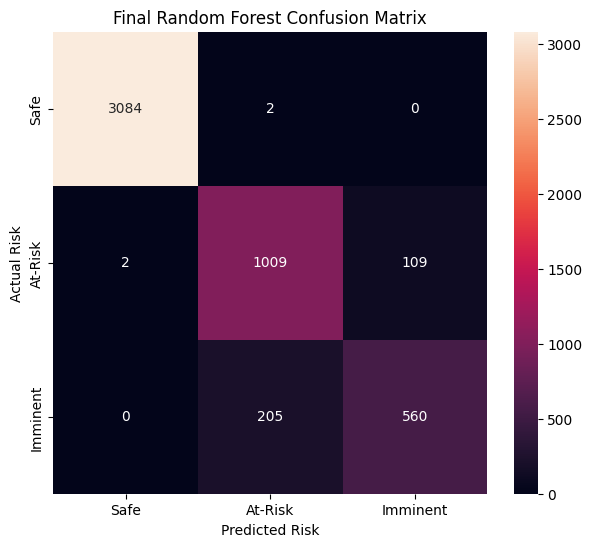

In [86]:
final_cm = confusion_matrix(
    y_test_final,
    final_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Safe", "At-Risk", "Imminent"],
    yticklabels=["Safe", "At-Risk", "Imminent"]
)

plt.title("Final Random Forest Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.show()

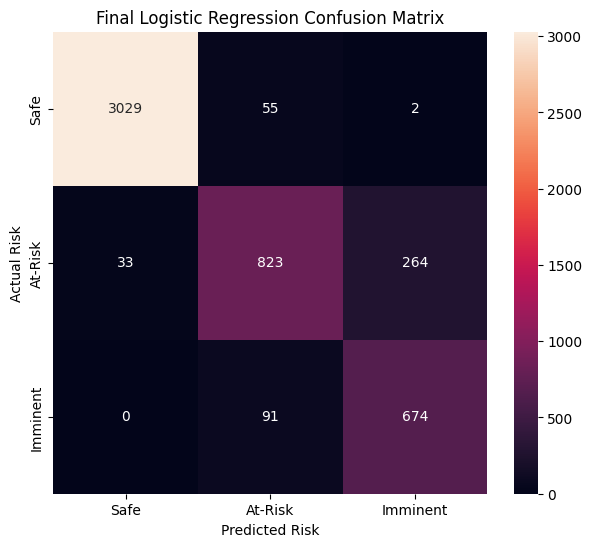

In [87]:
final_logistic_cm = confusion_matrix(
    y_test_final,
    logistic_final_pred,
    labels=["Safe", "At-Risk", "Imminent"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=["Safe", "At-Risk", "Imminent"],
    yticklabels=["Safe", "At-Risk", "Imminent"]
)

plt.title("Final Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.show()

In [88]:
coef = pd.DataFrame(
    logistic_final.coef_.T,
    index=features,
    columns=logistic_final.classes_
)

print(coef)

                          At-Risk  Imminent      Safe
opening_stock            0.248328 -0.073550 -0.174778
units_demanded          -0.435076  0.349265  0.085811
units_sold               0.192936 -0.267080  0.074144
closing_stock           -0.173661  0.039020  0.134640
reorder_point           -0.078380  0.020254  0.058126
lead_time_days_expected  1.146239  1.124413 -2.270652
sales_velocity_7d        0.030186  0.080748 -0.110934
days_of_cover           -1.618522 -1.908604  3.527126
reorder_gap              0.095280 -0.018766 -0.076514
days_of_cover_ratio      1.014201 -0.356675 -0.657526
stock_demand_ratio       0.025613 -0.091113  0.065500
demand_gap              -0.628012  0.616345  0.011667
reliability_score        2.011562 -0.598854 -1.412707
base_lead_time_days      1.146239  1.124413 -2.270652
lead_time_variance_days  0.336936  0.091713 -0.428649
shelf_life_days         -0.000212  0.002096 -0.001883
unit_price_inr           0.001678  0.001045 -0.002723
is_perishable            0.2

In [89]:
imminent_coef = coef["Imminent"].sort_values(
    key=abs,
    ascending=False
)

print("Top 10 features for Imminent risk:")
print(imminent_coef.head(10))

Top 10 features for Imminent risk:
days_of_cover             -1.908604
is_perishable              1.272536
lead_time_days_expected    1.124413
base_lead_time_days        1.124413
festive_relevant           0.873482
demand_gap                 0.616345
reliability_score         -0.598854
days_of_cover_ratio       -0.356675
units_demanded             0.349265
units_sold                -0.267080
Name: Imminent, dtype: float64


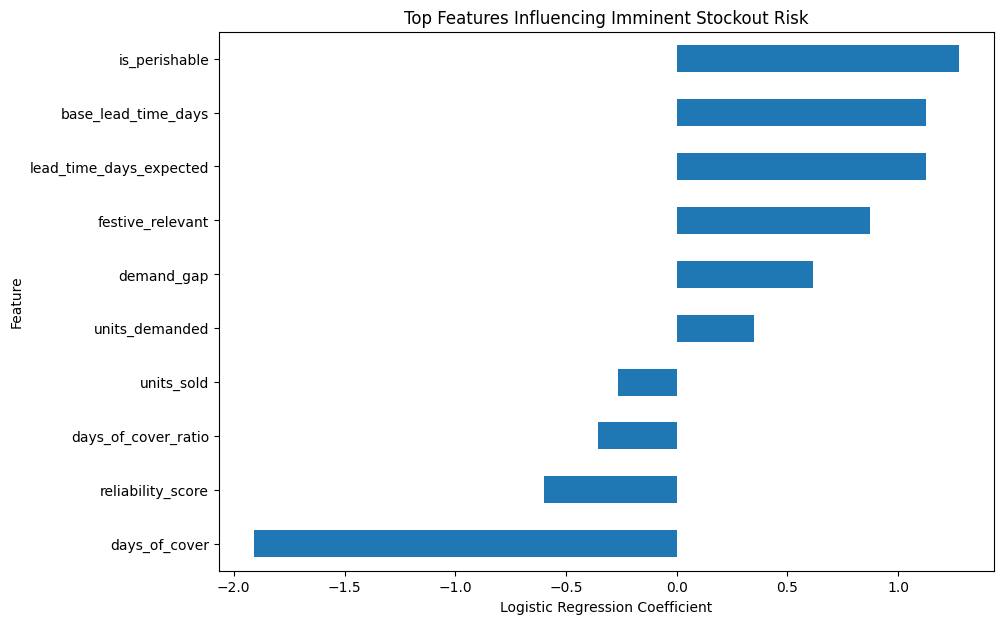

In [90]:
top_features = imminent_coef.head(10).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.title("Top Features Influencing Imminent Stockout Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [92]:
# Get the exact original rows used in the final test set
final_results = df.loc[test_final.index].copy()

# Add the model predictions
final_results["predicted_risk"] = logistic_final_pred

# Keep useful business columns
final_results = final_results[
    [
        "date",
        "store_id",
        "sku_id",
        "stockout_risk",
        "predicted_risk",
        "closing_stock",
        "units_demanded",
        "sales_velocity_7d",
        "days_of_cover",
        "reorder_point",
        "reliability_score"
    ]
]

print("Final prediction rows:", len(final_results))
print(final_results.head(10))

Final prediction rows: 4971
         date store_id  sku_id stockout_risk predicted_risk  closing_stock  \
23 2026-10-24     ST01  SKU001       At-Risk        At-Risk           34.8   
24 2026-10-25     ST01  SKU001          Safe           Safe          188.8   
25 2026-10-26     ST01  SKU001          Safe           Safe          162.8   
26 2026-10-27     ST01  SKU001          Safe           Safe          148.8   
27 2026-10-28     ST01  SKU001          Safe           Safe          131.8   
28 2026-10-29     ST01  SKU001          Safe           Safe          112.8   
29 2026-10-30     ST01  SKU001          Safe           Safe           99.8   
53 2026-10-24     ST02  SKU001          Safe           Safe           18.6   
54 2026-10-25     ST02  SKU001          Safe           Safe           15.6   
55 2026-10-26     ST02  SKU001          Safe        At-Risk           10.6   

    units_demanded  sales_velocity_7d  days_of_cover  reorder_point  \
23              18              12.57     

In [93]:
imminent_alerts = final_results[
    final_results["predicted_risk"] == "Imminent"
].copy()

print("Predicted Imminent cases:", len(imminent_alerts))

imminent_alerts.head(20)

Predicted Imminent cases: 940


,date,store_id,sku_id,stockout_risk,predicted_risk,closing_stock,units_demanded,sales_velocity_7d,days_of_cover,reorder_point,reliability_score
118,2026-10-29,ST04,SKU001,At-Risk,Imminent,13.7,9,9.57,1.43,19.7,0.83
173,2026-10-24,ST06,SKU001,Imminent,Imminent,9.7,11,8.86,1.10,27.8,0.83
174,2026-10-25,ST06,SKU001,Imminent,Imminent,0.0,18,9.54,0.00,27.8,0.83
204,2026-10-25,ST07,SKU001,Imminent,Imminent,3.4,8,3.43,0.99,9.8,0.83
354,2026-10-25,ST12,SKU001,At-Risk,Imminent,4.6,6,3.29,1.41,9.7,0.83
383,2026-10-24,ST01,SKU002,At-Risk,Imminent,51.5,31,22.29,2.31,88.4,0.73
384,2026-10-25,ST01,SKU002,Imminent,Imminent,22.5,29,24.29,0.93,88.4,0.73
415,2026-10-26,ST02,SKU002,Imminent,Imminent,18.2,11,8.43,2.16,28.1,0.73
416,2026-10-27,ST02,SKU002,Imminent,Imminent,8.2,10,8.86,0.93,28.1,0.73
417,2026-10-28,ST02,SKU002,Imminent,Imminent,3.2,5,8.29,0.39,28.1,0.73


In [94]:
priority_alerts = imminent_alerts.sort_values(
    ["days_of_cover", "closing_stock"],
    ascending=[True, True]
)

priority_alerts.head(20)

,date,store_id,sku_id,stockout_risk,predicted_risk,closing_stock,units_demanded,sales_velocity_7d,days_of_cover,reorder_point,reliability_score
174,2026-10-25,ST06,SKU001,Imminent,Imminent,0.0,18,9.54,0.0,27.8,0.83
563,2026-10-24,ST07,SKU002,Imminent,Imminent,0.0,17,11.87,0.0,47.6,0.73
1494,2026-10-25,ST02,SKU005,Imminent,Imminent,0.0,5,4.56,0.0,17.1,0.73
1584,2026-10-25,ST05,SKU005,Imminent,Imminent,0.0,25,15.45,0.0,56.9,0.73
1585,2026-10-26,ST05,SKU005,Imminent,Imminent,0.0,18,13.59,0.0,56.9,0.73
2184,2026-10-25,ST01,SKU007,Imminent,Imminent,0.0,57,55.77,0.0,223.0,0.73
2333,2026-10-24,ST06,SKU007,Imminent,Imminent,0.0,62,45.65,0.0,201.3,0.73
2664,2026-10-25,ST05,SKU008,Imminent,Imminent,0.0,18,12.99,0.0,35.8,0.83
2878,2026-10-29,ST12,SKU008,Imminent,Imminent,0.0,13,10.35,0.0,22.6,0.83
2904,2026-10-25,ST01,SKU009,Imminent,Imminent,0.0,44,39.37,0.0,138.2,0.73


In [95]:
final_results.to_csv(
    "QuickCart_Final_Stockout_Predictions.csv",
    index=False
)

priority_alerts.to_csv(
    "QuickCart_Priority_Alerts.csv",
    index=False
)

print("Final prediction files saved successfully!")

Final prediction files saved successfully!


In [96]:
print(final_results["predicted_risk"].value_counts())

predicted_risk
Safe        3062
At-Risk      969
Imminent     940
Name: count, dtype: int64


In [97]:
risk_summary = (
    final_results["predicted_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_summary)

predicted_risk
Safe        61.60
At-Risk     19.49
Imminent    18.91
Name: proportion, dtype: float64


In [98]:
store_risk = pd.crosstab(
    final_results["store_id"],
    final_results["predicted_risk"],
    normalize="index"
) * 100

store_risk = store_risk.sort_values(
    "Imminent",
    ascending=False
)

print(store_risk.round(2))

predicted_risk  At-Risk  Imminent   Safe
store_id                                
ST03              16.67     21.67  61.67
ST07              20.81     21.53  57.66
ST04              19.76     21.43  58.81
ST09              15.44     19.85  64.71
ST11              19.40     19.40  61.21
ST12              17.99     18.94  63.07
ST02              22.49     18.34  59.17
ST06              18.81     18.33  62.86
ST01              18.10     18.10  63.81
ST05              20.49     16.83  62.68
ST10              22.20     16.23  61.58
ST08              21.79     16.22  61.99


In [99]:
sku_risk = pd.crosstab(
    final_results["sku_id"],
    final_results["predicted_risk"],
    normalize="index"
) * 100

sku_risk = sku_risk.sort_values(
    "Imminent",
    ascending=False
)

print(sku_risk.head(15).round(2))

predicted_risk  At-Risk  Imminent   Safe
sku_id                                  
SKU059             3.57     63.10  33.33
SKU055            14.46     60.24  25.30
SKU060             5.95     58.33  35.71
SKU058            10.71     58.33  30.95
SKU023            18.75     56.25  25.00
SKU029            13.10     53.57  33.33
SKU056            20.00     52.50  27.50
SKU032            21.43     52.38  26.19
SKU018            16.67     51.19  32.14
SKU057            24.36     46.15  29.49
SKU030            32.05     35.90  32.05
SKU019            28.57     29.76  41.67
SKU022            14.29     29.76  55.95
SKU026            14.46     27.71  57.83
SKU033             5.95     27.38  66.67


In [100]:
urgent_alerts = final_results[
    final_results["predicted_risk"] == "Imminent"
].copy()

urgent_alerts["urgency_score"] = (
    (urgent_alerts["days_of_cover"] <= 1).astype(int) * 3
    + (urgent_alerts["closing_stock"] <= 0).astype(int) * 3
    + (urgent_alerts["closing_stock"] < urgent_alerts["reorder_point"]).astype(int) * 2
    + (urgent_alerts["reliability_score"] < 0.75).astype(int)
)

urgent_alerts = urgent_alerts.sort_values(
    ["urgency_score", "days_of_cover", "closing_stock"],
    ascending=[False, True, True]
)

urgent_alerts.head(20)

,date,store_id,sku_id,stockout_risk,predicted_risk,closing_stock,units_demanded,sales_velocity_7d,days_of_cover,reorder_point,reliability_score,urgency_score
563,2026-10-24,ST07,SKU002,Imminent,Imminent,0.0,17,11.87,0.0,47.6,0.73,9
1494,2026-10-25,ST02,SKU005,Imminent,Imminent,0.0,5,4.56,0.0,17.1,0.73,9
1584,2026-10-25,ST05,SKU005,Imminent,Imminent,0.0,25,15.45,0.0,56.9,0.73,9
1585,2026-10-26,ST05,SKU005,Imminent,Imminent,0.0,18,13.59,0.0,56.9,0.73,9
2184,2026-10-25,ST01,SKU007,Imminent,Imminent,0.0,57,55.77,0.0,223.0,0.73,9
2333,2026-10-24,ST06,SKU007,Imminent,Imminent,0.0,62,45.65,0.0,201.3,0.73,9
2904,2026-10-25,ST01,SKU009,Imminent,Imminent,0.0,44,39.37,0.0,138.2,0.73,9
3115,2026-10-26,ST08,SKU009,Imminent,Imminent,0.0,2,4.47,0.0,14.9,0.73,9
3176,2026-10-27,ST10,SKU009,Imminent,Imminent,0.0,21,19.29,0.0,70.3,0.73,9
3568,2026-10-29,ST11,SKU010,Imminent,Imminent,0.0,8,6.87,0.0,18.0,0.70,9


In [101]:
print("QUICKCART STOCKOUT RISK SUMMARY")
print("=" * 45)

print("Final test records:", len(final_results))

print(
    "Predicted Imminent:",
    (final_results["predicted_risk"] == "Imminent").sum()
)

print(
    "Predicted At-Risk:",
    (final_results["predicted_risk"] == "At-Risk").sum()
)

print(
    "Predicted Safe:",
    (final_results["predicted_risk"] == "Safe").sum()
)

print(
    "Zero-stock imminent alerts:",
    (
        (final_results["predicted_risk"] == "Imminent") &
        (final_results["closing_stock"] <= 0)
    ).sum()
)

QUICKCART STOCKOUT RISK SUMMARY
Final test records: 4971
Predicted Imminent: 940
Predicted At-Risk: 969
Predicted Safe: 3062
Zero-stock imminent alerts: 194


In [102]:
final_results.to_csv(
    "QuickCart_Final_Stockout_Predictions.csv",
    index=False
)

urgent_alerts.to_csv(
    "QuickCart_Urgent_Alerts.csv",
    index=False
)

store_risk.to_csv(
    "QuickCart_Store_Risk_Summary.csv"
)

sku_risk.to_csv(
    "QuickCart_SKU_Risk_Summary.csv"
)

print("All final project files saved successfully!")

All final project files saved successfully!


In [103]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Imminent Precision",
        "Imminent Recall",
        "Imminent F1"
    ],
    "Value": [
        accuracy_score(y_test_final, logistic_final_pred),
        balanced_accuracy_score(y_test_final, logistic_final_pred),
        precision_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test_final,
            logistic_final_pred,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    ]
})

final_metrics["Value"] = final_metrics["Value"].round(3)

final_metrics

,Metric,Value
0,Accuracy,0.910
1,Balanced Accuracy,0.866
2,Imminent Precision,0.717
3,Imminent Recall,0.881
4,Imminent F1,0.791


In [104]:
coef = pd.DataFrame(
    logistic_final.coef_.T,
    index=features,
    columns=logistic_final.classes_
)

imminent_coef = coef["Imminent"].sort_values(
    key=abs,
    ascending=False
)

print(imminent_coef.head(10))

days_of_cover             -1.908604
is_perishable              1.272536
lead_time_days_expected    1.124413
base_lead_time_days        1.124413
festive_relevant           0.873482
demand_gap                 0.616345
reliability_score         -0.598854
days_of_cover_ratio       -0.356675
units_demanded             0.349265
units_sold                -0.267080
Name: Imminent, dtype: float64


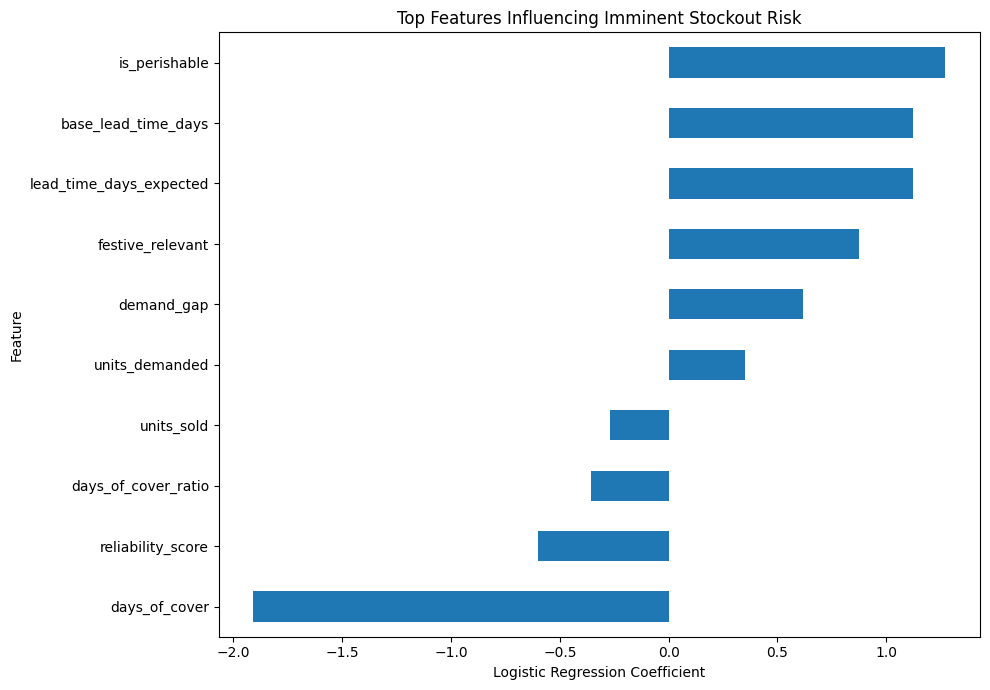

In [105]:
top_features = imminent_coef.head(10).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.title("Top Features Influencing Imminent Stockout Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

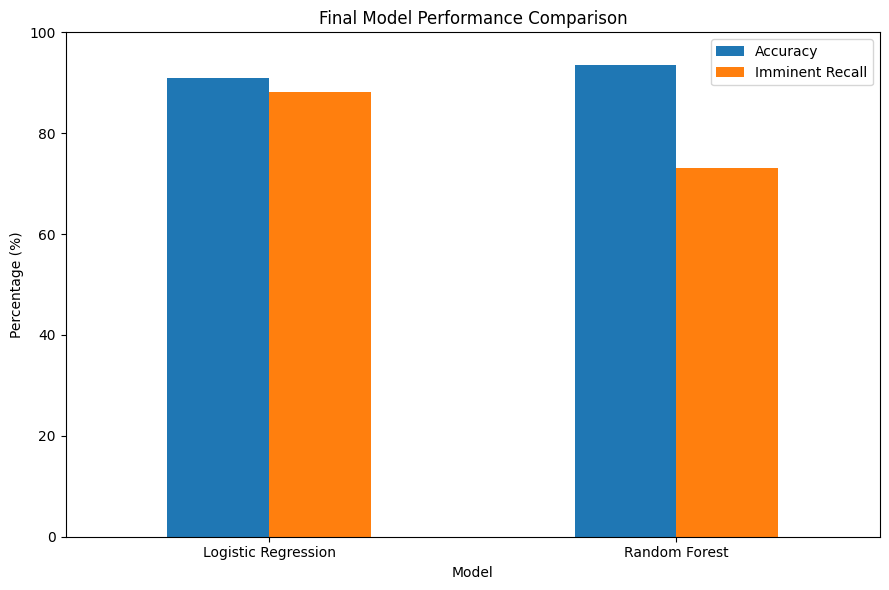

In [106]:
performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        91.0,
        93.6
    ],
    "Imminent Recall": [
        88.1,
        73.2
    ]
})

performance_plot = performance.set_index("Model")

performance_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [107]:
print("=" * 60)
print("QUICKCART STOCKOUT RISK PREDICTION - FINAL SUMMARY")
print("=" * 60)

print("\nDataset")
print("Total records:", len(df))
print("Stores:", df["store_id"].nunique())
print("SKUs:", df["sku_id"].nunique())
print("Suppliers:", df["supplier_id"].nunique())
print("Days:", df["date"].nunique())

print("\nFinal Model")
print("Model: Logistic Regression")
print("Accuracy: 91.0%")
print("Balanced Accuracy: 86.6%")
print("Imminent Precision: 71.7%")
print("Imminent Recall: 88.1%")
print("Imminent F1: 79.1%")

print("\nBusiness Alerts")
print(
    "Predicted Imminent cases:",
    len(imminent_alerts)
)

print(
    "Zero-stock Imminent cases:",
    (
        (final_results["predicted_risk"] == "Imminent") &
        (final_results["closing_stock"] <= 0)
    ).sum()
)

QUICKCART STOCKOUT RISK PREDICTION - FINAL SUMMARY

Dataset
Total records: 21600
Stores: 12
SKUs: 60
Suppliers: 13
Days: 30

Final Model
Model: Logistic Regression
Accuracy: 91.0%
Balanced Accuracy: 86.6%
Imminent Precision: 71.7%
Imminent Recall: 88.1%
Imminent F1: 79.1%

Business Alerts
Predicted Imminent cases: 940
Zero-stock Imminent cases: 194


The QuickCart Stockout Risk Prediction system successfully predicts daily inventory stockout risk across stores and SKUs. Logistic Regression was selected as the final operational model because it achieved 91.0% accuracy, 86.6% balanced accuracy, and 88.1% recall for the critical Imminent class on an untouched time-based test set. The model identified 674 of 765 actual imminent stockout cases. Feature analysis showed that days of inventory cover, perishability, supplier lead time, festival relevance, demand pressure, and supplier reliability are important drivers of stockout risk. The resulting prediction system can support proactive replenishment and help QuickCart prioritize inventory requiring immediate attention.
